In [1]:
# In this notebook you'll learn to forecast using AutoARIMA. Steps:
# 1. Prepare data for time series forecasting
# 2. Create a baseline model using AutoARIMA from StatsForecast
# 3. Compare the outputs
#
# - References:
#   https://nixtlaverse.nixtla.io/statsforecast/docs/getting-started/getting_started_complete.html
#   https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/statisticalneuralmethods.html
#   https://www.ons.gov.uk/employmentandlabourmarket/peoplenotinwork/unemployment/timeseries/mgsx/lms

In [2]:
from pandas import DataFrame, read_csv, to_datetime, PeriodIndex, concat
from statsforecast.models import AutoARIMA, HoltWinters
from utilsforecast.losses import rmse, smape
from statsforecast import StatsForecast
from os.path import isfile
import wget

ModuleNotFoundError: No module named 'statsforecast'

In [3]:
# Download suitable time series data:
# Unemployment rate in the UK (aged 16 and over, seasonally adjusted)

filename = 'unemployment_raw_data.csv'
url = 'https://www.ons.gov.uk/generator?format=csv&uri=/employmentandlabourmarket/peoplenotinwork/unemployment/timeseries/mgsx/lms'

if not isfile(filename):
    print(f"Downloading {filename}")
    wget.download(url, filename)
else:
    print(f"Reading {filename}")

df = read_csv(filename, skiprows=8, header=None)

In [4]:
# 1. Data preparation: that's how raw data look like
df.columns = ['Period', 'Pct' ]
df

# Period is not homegeneous & index is not prepared for time series

,Period,Pct
0,1971,4.1
1,1972,4.3
2,1973,3.7
3,1974,3.7
4,1975,4.5
...,...,...
923,2025 APR,4.7
924,2025 MAY,4.7
925,2025 JUN,4.7
926,2025 JUL,4.8


In [5]:
# 1. Data preparation: do we have missing values?
df.isnull().sum().sum()

# no, we don't have missing values

np.int64(0)

<Axes: title={'center': 'Incorrect index and mixed sampling frequencies'}>

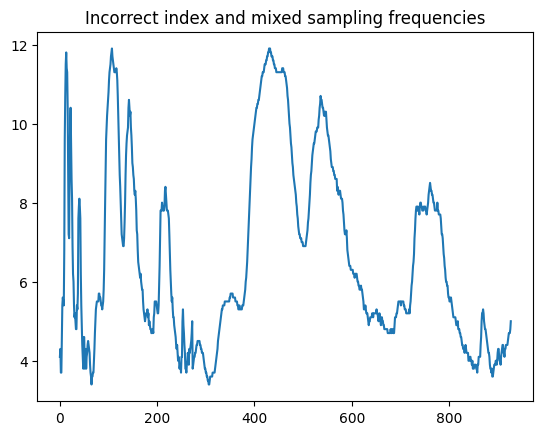

In [6]:
# 1. Data preparation: plot the incorrect time series

df['Pct'].plot(title='Incorrect index and mixed sampling frequencies')

In [7]:
# 1. Data preparation: It looks good to have monthly estimates, so we can remove the summary ones (e.g. 2024) or quarterly estimates (e.g. 1974 Q3)

# focus on those monthly estimates: yyyy-mmm
df['Year'] = df['Period'].str.split(n=2, expand=True)[0]
df['Month'] = df['Period'].str.split(n=2, expand=True)[1]

df['Period'].str.split(n=2, expand=True)        # getting better, almost there for yyyy-mm

,0,1
0,1971,None
1,1972,None
2,1973,None
3,1974,None
4,1975,None
...,...,...
923,2025,APR
924,2025,MAY
925,2025,JUN
926,2025,JUL


In [8]:
# 1. Data preparation: it's time to join yyyy to mm and create a monthly index (freq='M')

df['Period'] = to_datetime(df['Year']+df['Month'], format="%Y%b", errors='coerce').dt.strftime('%Y-%m')
df.drop(columns=['Year', 'Month'], inplace=True)    # no need to keep those temporary columns
df.dropna(inplace=True, ignore_index=True)      # only keep records aligned with yyyy-mm
df.drop_duplicates(subset=['Period'], inplace=True)     # in case we have repeated estimates
df.set_index(PeriodIndex(df['Period'], freq='M'), inplace=True, verify_integrity=True)          # M for monthly samples
df.to_csv('unemployment.csv', index=False)

df   # Finally, period is now formatted as yyyy-mm

,Period,Pct
Period,,
1971-02,1971-02,3.8
1971-03,1971-03,3.9
1971-04,1971-04,4.0
1971-05,1971-05,4.1
1971-06,1971-06,4.1
...,...,...
2025-04,2025-04,4.7
2025-05,2025-05,4.7
2025-06,2025-06,4.7


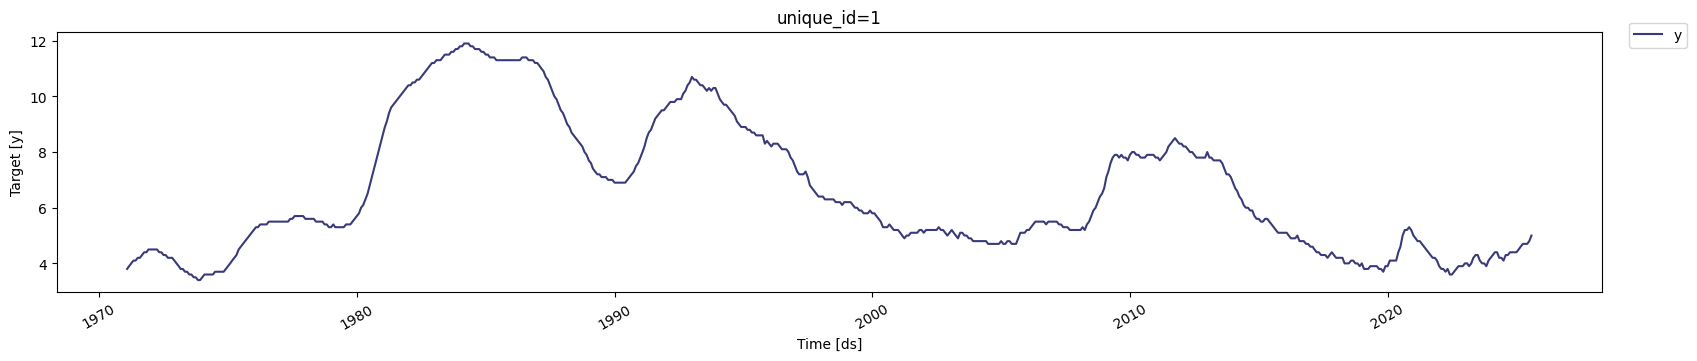

In [9]:
# 1. Data preparation: StatsForecast accepts data frames with three columns: unique_id, ds and y

df['unique_id'] = 1
df.rename(columns={'Period': 'ds', 'Pct': 'y'}, inplace=True)

StatsForecast.plot(df)

In [10]:
# 2. Create a baseline model: StatsForecast allows you to run multiple algorithms at once

season_length=12         # assuming 12 months unemployment period / cycle, any other guess?
h=6                      # forecast next 6 months
level=[95]               # generate 95% confidence intervals

model = StatsForecast(
    models=[
        HoltWinters(season_length=season_length),
        AutoARIMA(season_length=season_length, biasadj=True)
    ],
    freq='ME',           # monthly estimates
    n_jobs=-1
)

forecasts_df = model.forecast(h=h, df=df, level=level, fitted=True)
forecasts_df

,unique_id,ds,HoltWinters,HoltWinters-lo-95,HoltWinters-hi-95,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-hi-95
0,1,2025-08-31,5.001358,4.793024,5.209693,5.103546,4.944510,5.262583
1,1,2025-09-30,5.006568,4.710686,5.302451,5.197898,4.941412,5.454384
2,1,2025-10-31,5.007663,4.642745,5.372581,5.271884,4.906828,5.636940
3,1,2025-11-30,5.016775,4.592177,5.441373,5.330113,4.860618,5.799609
4,1,2025-12-31,5.025587,4.547125,5.504048,5.389632,4.815633,5.963632
5,1,2026-01-31,5.032695,4.504381,5.561009,5.431489,4.748883,6.114094


In [11]:
# 2. Create a baseline model: see the in-sample predictions (training accuracy)
insample_df = model.forecast_fitted_values()
insample_df

,unique_id,ds,y,HoltWinters,HoltWinters-lo-95,HoltWinters-hi-95,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-hi-95
0,1,1971-02-01,3.8,3.752671,3.544500,3.960843,3.796200,3.637164,3.955236
1,1,1971-03-01,3.9,3.810827,3.602656,4.018998,3.823626,3.664589,3.982662
2,1,1971-04-01,4.0,3.916325,3.708154,4.124496,3.956324,3.797288,4.115360
3,1,1971-05-01,4.1,3.994591,3.786420,4.202762,4.070078,3.911042,4.229115
4,1,1971-06-01,4.1,4.109282,3.901111,4.317453,4.169028,4.009991,4.328064
...,...,...,...,...,...,...,...,...,...
650,1,2025-04-01,4.7,4.605922,4.397750,4.814093,4.668030,4.508994,4.827067
651,1,2025-05-01,4.7,4.703525,4.495354,4.911696,4.742225,4.583189,4.901262
652,1,2025-06-01,4.7,4.694974,4.486803,4.903145,4.767529,4.608493,4.926565
653,1,2025-07-01,4.8,4.701863,4.493692,4.910034,4.731544,4.572508,4.890581


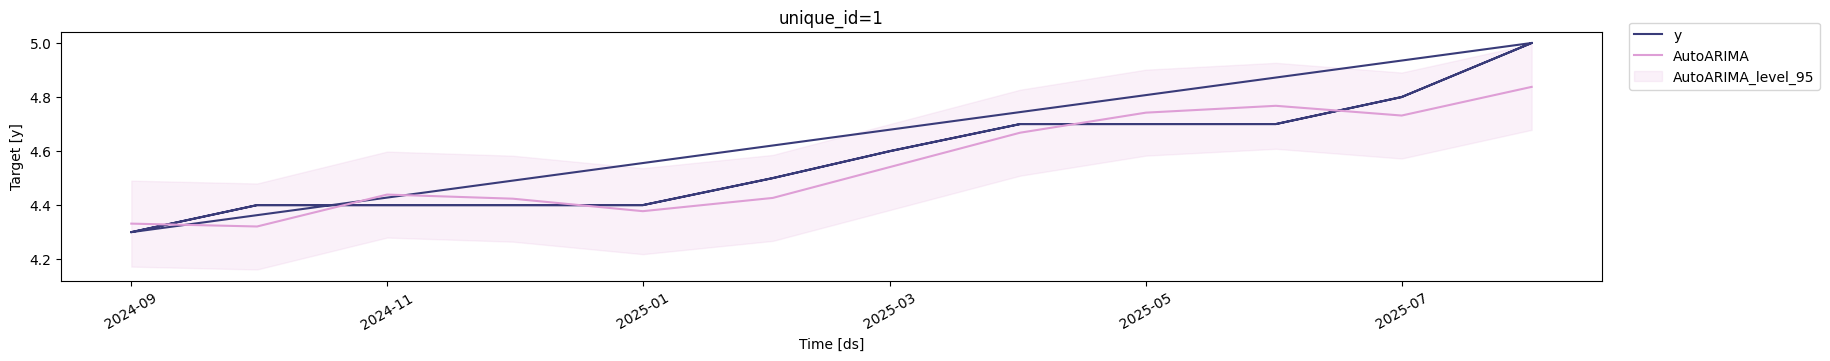

In [12]:
# 2. Create a baseline model: plot the in-sample predictions
StatsForecast.plot(df[-12:], insample_df[-12:], level=level, models=['AutoARIMA'])

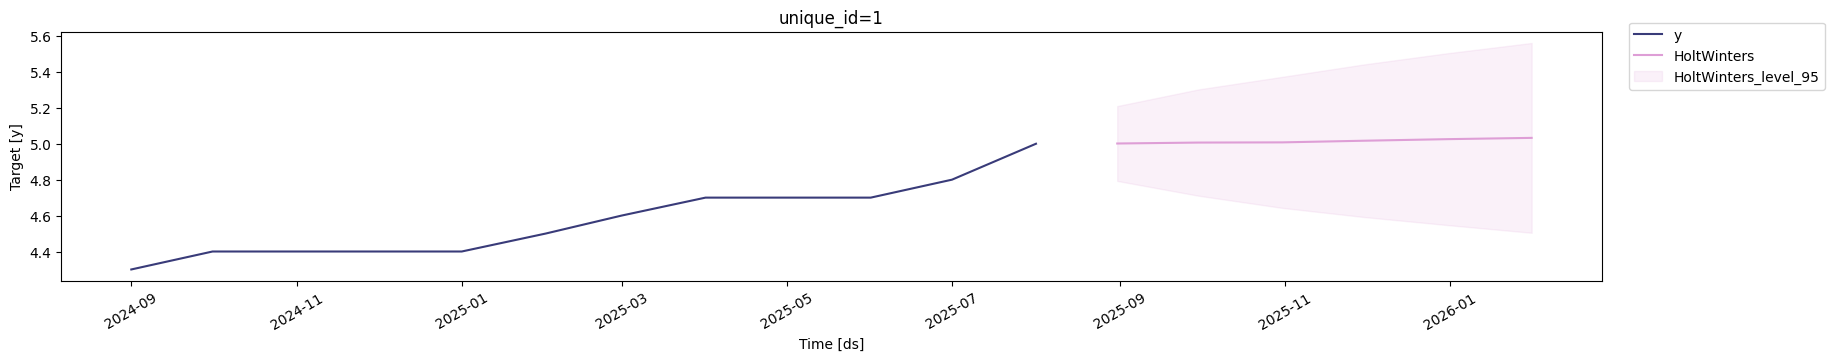

In [13]:
# 2. Create a baseline model: Here's HoltWinters forecast
StatsForecast.plot(df[-12:], forecasts_df, level=level, models=['HoltWinters'])

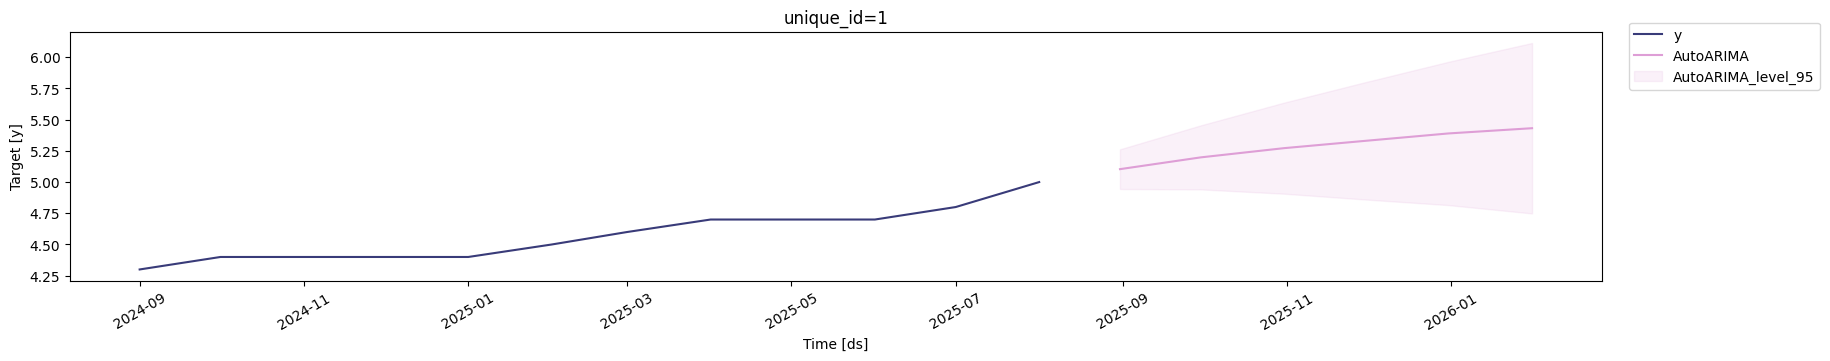

In [14]:
# 2. Create a baseline model: Here's AutoARIMA forecast
StatsForecast.plot(df[-12:], forecasts_df, level=level, models=['AutoARIMA'])

In [15]:
# 2. Create a baseline model: Get model performance using (temporal) 10-fold CV

cv_df = model.cross_validation(h=h, df=df, n_windows=10)
cv_df.head()

,unique_id,ds,cutoff,y,HoltWinters,AutoARIMA
0,1,2024-06-01,2024-05-01,4.2,4.186625,4.205104
1,1,2024-07-01,2024-05-01,4.1,4.188100,4.162416
2,1,2024-08-01,2024-05-01,4.3,4.174180,4.163339
3,1,2024-09-01,2024-05-01,4.3,4.159370,4.159184
4,1,2024-10-01,2024-05-01,4.4,4.155390,4.110844


In [16]:
# 2. Create a baseline model: which one is better?

# Adapted from https://nixtlaverse.nixtla.io/statsforecast/docs/getting-started/getting_started_complete.html
def evaluate_cv2(df, metrics):
    # empty data frame to store results
    cols = cv_df.columns.drop(['ds', 'cutoff', 'y']).to_list()
    cols.append('metric')
    cols.append('best')
    results = DataFrame(columns=cols)

    for metric in metrics:
        # evaluate each model
        models = df.columns.drop(['unique_id', 'ds', 'y', 'cutoff']).tolist()
        evals = metric(df, models=models)
        evals['best'] = evals[models].idxmin(axis=1)
        evals['metric'] = metric.__name__
        # concatenate results per metric
        df_list = [ results, evals ]
        results = concat([df for df in df_list if not df.empty], ignore_index=True)         # concatenate potentially empty data frames
    return results

In [17]:
# 2. Create a baseline model: AutoARIMA got 0.193894 for RMSE and 0.017032 for sMAPE
evaluation_df = evaluate_cv2(cv_df, metrics=[rmse, smape])
evaluation_df

,unique_id,HoltWinters,AutoARIMA,best,metric
0,1,0.223492,0.193894,AutoARIMA,rmse
1,1,0.021536,0.017032,AutoARIMA,smape
